In [1]:
import numpy as np
import csv
import math 
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LogNorm
import matplotlib.cm as cm
import os

#import sys
# todos los ángulos estan en grados


file_raster = './rastert_dem_uni1-clean.txt' ## DEM file 
#file_shower_txt = './energia_split_data_3.txt' ## file de energía
#file_shower_txt = '~/Work/split_files3/Dlim-2201-01_08640007.txt' ## file de energía

#file_shower_folder = '~/Work/test2/' ## file de energía

fila = 22 ## (por qué?)
n,m = 300,125 #punto de observación (X,h)
apertura = 15 #apertura del ángulo 
escala_satelite = 3 # escala en X de acuerdo a datos de CONIDA (unidades?)

angle_observation = 270 # ángulo phi de observación en coordenadas de CORSIKA

phi1, phi2 = 269, 271 #posición de observación en coordenadas de CORSIKA
anglet = 3 #apertura en azimutal

beta1, beta2 = 25, 28 

In [2]:
## inicio del programa 

cmap = plt.colormaps['viridis']

num_colors = 20
color = cmap(np.linspace(0, 1, num_colors))

## línea de visión 
def recta(x_0, y_0, x, angulo): # todos los puntos son conocidos, la función bota un punto adelante 
 #   print(x_0, y_0, x, angulo)
    y_recta= y_0+np.tan(np.radians(angulo))*(x-x_0)     

    return y_recta 
 
############################ 
# calcula el p0
# compara el array del cerro con la recta y da el valor de intersección
# pt_ob = (pt_obx, pt_oby) , array = valor en y del objeto cerro , array_recta = valores de y de la recta en la
# array_x = valores en x
# dirección de observación 

def pto_0(pt_ob, array_x, array): 
    for i in range(pt_ob[0], len(array_x)):
        if pto_0[1]==array[i]: 
            pto_inicial= i
    return (pto_inicial, pto_0[1])

def indice_p2(pt_ob, array_x, array_cerro, array_recta):  #indice final de cruce 
    indice_inicial = 0
    for i in range(pt_ob[0], len(array_x)):
        if (array_recta[i]-array_cerro[i])<0: 
            indice_inicial = i            
                
    return (indice_inicial, array_cerro[indice_inicial])

def indice_p1(pt_ob, array_x, array_cerro, array_recta):  #indice inicial de cruce  array_cerro: es la data de raster
    indice_final = 0
    for i in range(pt_ob[0], len(array_x)):
        if (array_recta[i]-array_cerro[i])<0: 
            indice_final = i
            break
                
    return (indice_final, array_cerro[indice_final])
    
def distancia(p1, p2): #distancia entre dos puntos 
 
    dist = math.sqrt((p2[1]-p1[1])**2 + ((p2[0]-p1[0])*escala_satelite)**2)  
    return dist  

In [3]:
## CÁLCULO DEL LA ELEVACIÓN MÁXIMA DE OBSERVACION


def angulo_maximo(arr_x, np_array, p): #arra_x: indices en el eje X, fila: fila de analisis, p: punto de observación 
        vec_picos = []
        vec  = []
        ind_z = 0 
        ind_x = 0 
    
        for j in range(p[0], len(arr_x)): 
            if np_array[j] > ind_z:
                ind_z = np_array[j]
                ind_x = j 
    
        vec_picos.append(ind_x)
        vec_picos.append(ind_z)

        h_max = ind_z-p[1]
        x_max = arr_x[ind_x]-p[0]  
    
        phi_max = np.degrees(np.arctan2(h_max,x_max))

#        print(ind_z,ind_x,h_max,x_max,phi_max)
    
        return (vec_picos, phi_max) #ángulo en grados

In [4]:
#ecuaciones de pérdida de energía 

def funciondEdX_lesparre(E):  
    l4 = 0.0154 
    l3 = -0.0461 
    l2 = 0.0368
    l1 = 0.0801
    l0 = 0.2549
    y = math.log10(E)
    dEdx = 10**(l4*y**4+l3*y**3+l2*y**2+l1*y**1+l0)
    
    return dEdx
        

def funciondEdX_tesis(E): 
    me = 0.0005285 #GeV/c2
    mu = 0.1057 #GeV/c2
    
    Emax = (E**2)/(E+(mu**2)/(2*me))
    dEdx = (1.84 + 0.076* np.log(Emax/(mu)))
     
    return dEdx
        
#################################  

def perdida_energia_total(E, d): #energia y distancia por recorrer segun lesparre

    E = E*1000  #(E in Mev)
    step_size = 1 #m
    avg_dens = 2.64 #g/cm^3

#    print("Initial parameters (Lesparre) - Energy:",E,"d:",d,"step_size:",step_size)
    
    total_loss = 0
    j=0
#    for _ in np.arange(0, d, step_size):
    for j in range(0,d): # distancia en metros --> step_size en metros (unidades ) 
        j=j+1
        dE_dx = funciondEdX_lesparre(E)
        energy_loss = dE_dx * step_size * avg_dens # Energy loss in the step        
        E = E - energy_loss
    
        if E < 0 : 
            control = False
            break 
        control = True

        #print(j,"dEdx:",dE_dx,"E loss:",energy_loss,"E:",E)
    
    energia_final = E 
    
    return (energia_final, control)
    #Control True = pasó, False = no pasó

#################################  

def perdida_energia_total_hueco(E, d, temp_angulo_shower, beta1, beta2): #energia y distancia por recorrer segun lesparre. Control es usado para cuando haya vacios

    E = E*1000  #(E in Mev)
    step_size = 1 #m
    avg_dens = 2.64 #g/cm^3

#    print("Initial parameters (Lesparre) - Energy:",E,"d:",d,"step_size:",step_size)
    
    total_loss = 0
    j=0
#    for _ in np.arange(0, d, step_size):
    for j in range(0,d): # distancia en metros --> step_size en metros (unidades ) 
        j=j+1
        dE_dx = funciondEdX_lesparre(E)

        if  beta1 <= temp_angulo_shower <=  beta2: 
        
            if j < round(4*d/10):         
                energy_loss = dE_dx * step_size * avg_dens # Energy loss in the step        
            if j > round(4*d/10)+1 or j < round(6*d/10): 
                energy_loss = 0 # Energy loss in the step with no material
            if j > round(6*d/10)+1: 
                energy_loss = dE_dx * step_size * avg_dens # Energy loss in the step        
        else: 
            energy_loss = dE_dx * step_size * avg_dens # Energy loss in the step      
            
        E = E - energy_loss
    
        if E < 0 : 
            control = False
            break 
        control = True

        #print(j,"dEdx:",dE_dx,"E loss:",energy_loss,"E:",E)
    
    energia_final = E  
  
    
    return (energia_final, control)
    #Control True = pasó, False = no pasó

################################

def perdida_energia_total_tesis(E, d): #energia y distancia por recorrer segun lesparre

    E_t = E*1000  #(E in Mev)
    step_size = 1 #m
    avg_dens = 2.64 #g/cm^3

#    print("Initial parameters (Tesis) - Energy:",E_t,"d:",d,"step_size:",step_size)
    
    total_loss = 0
    j=0
#    for _ in np.arange(0, d, step_size):
    for j in range(0,d): # distancia en metros --> step_size en metros (unidades 
        j=j+1
        dE_dx_t = funciondEdX_tesis(E_t)
        energy_loss_t = dE_dx_t * step_size * avg_dens # Energy loss in the step        
        E_t = E_t - energy_loss_t
    
        if E_t < 0 : 
            control_t = False
            break 
        control_t = True

        #print(j,"dEdx:",dE_dx,"E loss:",energy_loss,"E:",E)
    
    energia_final_t = E_t 
    
    return (energia_final_t, control_t)
    #Control True = pasó, False = no pasó

#################################  
   
## Diccionario de distancias 

def acceder_diccionario(diccionario, valor_clave):
    valor_distancia = 0 
    for clave, valor in diccionario.items(): 
        if clave == valor_clave: 
            valor_distancia = diccionario[valor_clave]
    return valor_distancia 

In [5]:
df  = pd.read_csv(file_raster, sep =" ", header=None)# Lee los datos del raster del objeto
df  = df.fillna(0)
df  = df.drop(columns=626)#eliminar la última columna  (columna principalmente de ceros)

#print(df)

#dimensionalidad del raster
n_col = df.shape[1] 
n_fil = df.shape[0]

arr_z_cerro = []
arr_x = np.linspace(0,n_col-1,n_col) #crea los índices en x (n_col) para iterar 

#arr_x = np.linspace(0,n_col-1,n_col) #crea los índices en x (n_col) para iterar 

pt_ob = [n,m] #punto de observación (300,120) -> (x,h)
arr_z_cerro = df.iloc[fila].to_numpy() #elevación del cerro en una determinada fila

ang_max = int(np.round(angulo_maximo(arr_x, arr_z_cerro, pt_ob)[1])) #ángulo máximo de observación para una fila 

theta1, theta2 = ang_max - apertura, ang_max-2.0 #angulos de observación para una fila dada i límites de observación

In [6]:
################################# IMPORTANTE #################################
#df_shower_txt3 = df_shower_txt

#df_shower_txt  = pd.read_csv(file_shower_txt, sep =" ")# Lee los datos del shower en energia y ángulo

#df_shower_txt3 = df_shower_txt[(df_shower_txt['part'] ==5) | (df_shower_txt['part'] ==6)] #<---------------------
#data_shower = df_shower_txt3.sort_values(by=df_shower_txt3.columns[1]) #data ordered by phi angle

########### IMPORTANTE #################################

#dfshower_pre_filtrado = data_shower[ (data_shower['phit'] >= angle_observation-anglet) & (data_shower['phit'] <= angle_observation+anglet) &(data_shower['thetat'] >= theta1) & (data_shower['thetat'] <= ang_max)]

#dfshower_pre_filtrado = data_shower[ (data_shower['thetat'] >= theta1) & (data_shower['thetat'] <= ang_max)] #data selected by theta angle limits
#dfshower_filtrado = dfshower_pre_filtrado.drop('part', axis=1) 

#print(dfshower_filtrado)

# de archivo 1
# de archivo 2
# de archivo 3
# de archivo 4
# de archivo 5
# de archivo 6
# de archivo 7
# de archivo 8
# de archivo 9
# de archivo 10
# de archivo 11
# de archivo 12
# de archivo 13
# de archivo 14
# de archivo 15
# de archivo 16
# de archivo 17
# de archivo 18
# de archivo 19
# de archivo 20
# de archivo 21
# de archivo 22
# de archivo 23
# de archivo 24
# de archivo 25
# de archivo 26
# de archivo 27
# de archivo 28
# de archivo 29
# de archivo 30
# de archivo 31
# de archivo 32
# de archivo 33
# de archivo 34
# de archivo 35
# de archivo 36
# de archivo 37
# de archivo 38
# de archivo 39
# de archivo 40
# de archivo 41
# de archivo 42
# de archivo 43
# de archivo 44
# de archivo 45
# de archivo 46
# de archivo 47
# de archivo 48
# de archivo 49
# de archivo 50
# de archivo 51
# de archivo 52
# de archivo 53
# de archivo 54
# de archivo 55
# de archivo 56
# de archivo 57
# de archivo 58
# de archivo 59
# de archivo 60
# de archivo 61
# de archivo 62
# de archivo 63
#

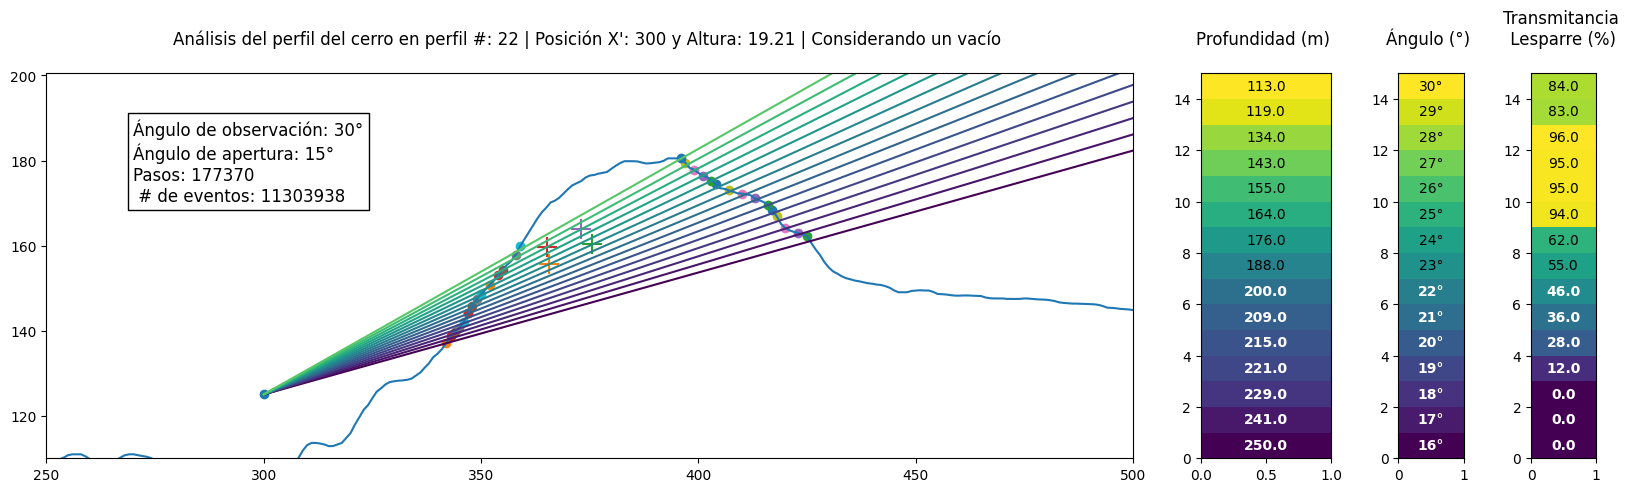

In [8]:

# Ruta del directorio que quieres recorrer
#directorio = '/home/cesarc/Work/test2/'
directorio = '/home/cesarc/Work/split_files3/'

#fig, axs = plt.subplots(1, 5,figsize=(20,5), gridspec_kw={'width_ratios': [5, 0.6,0.3,0.3,0.3]})  # 2 filas, 1 columna de subplots
fig, axs = plt.subplots(1, 4,figsize=(20,5), gridspec_kw={'width_ratios': [5, 0.6,0.3,0.3]})  # 2 filas, 1 columna de subplots

####################################################################################################
#PLOT 0 del perfil UNI y puntos de intersección 
############ 
axs[0].plot(arr_z_cerro)
axs[0].scatter(pt_ob[0], pt_ob[1])

punto_alfa = 0 
punto_beta = 0

punto_gamma = 0
punto_epsilon = 0

#coordenadas (x,h) de intersección entre la proyección de observación y el perfil del cerro, para cada ángulo analizado
vec_dis=[] #vector con la fila, el ángulo de observación y la profundidad
j=0
p2_max = 0
axs[0].set_title("Análisis del perfil del cerro en perfil #: "+ str(fila)+" | Posición X': "+str(n)+ " y Altura: "+ str(np.round(m-arr_z_cerro[n],2)) + ' | Considerando un vacío \n') 

for th_i in range(theta1, ang_max,1):
    h_line = recta(pt_ob[0], pt_ob[1], arr_x, th_i)
    p2 = indice_p2(pt_ob, arr_x, arr_z_cerro, h_line)  #ptos obs, indice de columnas, alturas de la fila seleccionada, array de alturas (puntos) de la recta para diferentes ángulos
    p1 = indice_p1(pt_ob, arr_x, arr_z_cerro, h_line) 


    if th_i == beta1: 
        punto_alfa = p1  
        punto_beta = p2

    if th_i == beta2: 
        punto_gamma = p1 
        punto_epsilon = p2 

    if (p2[0]>p2_max): #upper limit to project the line
        p2_max = p2[0]+30
    
#    print(p1,p2,p2_max)

    if (p2[0]!=0) or (p1[0]!=0):         
        axs[0].plot(arr_x[n:], h_line[n:], color=color[j])    #proyecciones de observación
        axs[0].scatter(p1[0], p1[1]) #ptos. de observación inicial
        axs[0].scatter(p2[0], p2[1]) #ptos. de observación final

        d = (distancia(p1,p2))
        evento = [fila,th_i,d]  #los valores registrados son azimutales, los valores en el plot son elevación
        elevacion_max = th_i 
        vec_dis.append(evento)  # fila, th_i angulo de observación, distancia 
        j=j+1 #indice para los colores

### vec_dis es un archivo con fila, angulo de observacion y distancia 
#vec_dis = [fila, ángulo, distancia] 

## punto alpha  



#######################################################----------------------------#
### Creacion de diccionario 

diccionario = {}  # Inicializar el diccionario vacío
#Recordar que vec_dis = [fila, angulo, distancia] 
for i in range(0, len(vec_dis)):  # Bucle for para generar claves del 1 al 5
    clave = vec_dis[i][1] #valores de distancia
    valor = vec_dis[i][2] #valores de ángulos    
    diccionario[clave] = valor  # Agregar clave-valor al diccionario  
 
######################################################################################
# ESPACIO VACIO 


distancia_alfa = np.sqrt(((punto_alfa[1]-pt_ob[1])**2+(punto_alfa[0]*escala_satelite-pt_ob[0]*escala_satelite)**2))+ acceder_diccionario(diccionario, beta1)*4/10  
alfa = [np.cos(np.radians(beta1))*distancia_alfa/3+pt_ob[0], np.sin(np.radians(beta1))*distancia_alfa/3+pt_ob[1]]

## punto gamma 

distancia_gamma = np.sqrt(((punto_gamma[1]-pt_ob[1])**2+(punto_gamma[0]*escala_satelite-pt_ob[0]*escala_satelite)**2))+ acceder_diccionario(diccionario, beta2)*4/10  
gamma = [np.cos(np.radians(beta2))*distancia_gamma/3+pt_ob[0], np.sin(np.radians(beta2))*distancia_gamma/3+pt_ob[1]]

## punto beta  

distancia_beta = np.sqrt(((punto_beta[1]-pt_ob[1])**2+(punto_beta[0]*escala_satelite-pt_ob[0]*escala_satelite)**2))- acceder_diccionario(diccionario, beta1)*4/10  
beta = [np.cos(np.radians(beta1))*distancia_beta/3+pt_ob[0], np.sin(np.radians(beta1))*distancia_beta/3+pt_ob[1]]

## punto epsilon

distancia_epsilon = np.sqrt(((punto_epsilon[1]-pt_ob[1])**2+(punto_epsilon[0]*escala_satelite-pt_ob[0]*escala_satelite)**2))- acceder_diccionario(diccionario, beta2)*4/10  
epsilon = [np.cos(np.radians(beta2))*distancia_epsilon/3+pt_ob[0], np.sin(np.radians(beta2))*distancia_epsilon/3+pt_ob[1]]



axs[0].scatter(alfa[0], alfa[1], marker='+', s= 200)
axs[0].scatter(beta[0], beta[1], marker='+', s= 200)
axs[0].scatter(gamma[0], gamma[1], marker='+', s= 200)
axs[0].scatter(epsilon[0], epsilon[1], marker='+', s= 200)



#######################################################----------------------------#
### Registra distancias para los angulos disponibles 

a_vec_dis=[] #vector con los valores de profundidad desde un punto de observación dado por vec_dis. 
for i in range(len(vec_dis)):
    r = vec_dis[i][2] #registra solo la distancia 
    a_vec_dis.append(np.round(r,0))

a_vec_dis = np.array(a_vec_dis) #registra las distancias de los ángulos disponibles para la observación desde un punto de observación 
a_vec_dis = a_vec_dis[::-1] #ordena de menor a mayor

#######################################################----------------------------#
### Vector con los valores de profundidad tomada de vec dis
b_vec_dis=[] #vector con los valores de profundidad tomada de vec_dis
#vec_dis = [fila, ángulo, distancia] 

for i in range(len(vec_dis)):
    rr = vec_dis[i][1] #registra solo los ángulos 
    b_vec_dis.append(np.round(rr,2))

b_vec_dis = np.array(b_vec_dis)
b_vec_dis=b_vec_dis[::-1] 

matriz = np.tile(a_vec_dis, (1,1))
matriz_rotada_distancias_observacion = np.rot90(matriz)

 
 

########################################################################################################## 
#PLOT 1 de la distancia
############ 

axs[1].set_title("Profundidad (m) \n")

im = axs[1].pcolormesh(matriz_rotada_distancias_observacion,cmap="viridis_r")

for i in range(matriz_rotada_distancias_observacion.shape[0]):
    for j in range(matriz_rotada_distancias_observacion.shape[1]): 
        if i <= 6:         
            axs[1].text(j+0.5, i+0.5, str(matriz_rotada_distancias_observacion[i,j]), fontweight='bold',  color='white', ha='center', va='center')
        else: 
            axs[1].text(j+0.5, i+0.5, str(matriz_rotada_distancias_observacion[i,j]), color='black', ha='center', va='center')






########################################################################################################## 
#PLOT 2: Ángulos de observación con distancia diferente de 0 
############

matriz_2 = np.tile(b_vec_dis, (1,1))
matriz_rotada_angulos_observacion = np.rot90(matriz_2)

axs[2].set_title("Ángulo (°) \n")

io = axs[2].pcolormesh(matriz_rotada_angulos_observacion,cmap="viridis")

for i in range(matriz_rotada_angulos_observacion.shape[0]):
    for j in range(matriz_rotada_angulos_observacion.shape[1]):
        if i <= 6:         
            axs[2].text(j+0.5, i+0.5, str(matriz_rotada_angulos_observacion[i,j])+'°', fontweight='bold',color='white', ha='center', va='center')
        else: 
            axs[2].text(j+0.5, i+0.5, str(matriz_rotada_angulos_observacion[i,j])+'°',  color='black', ha='center', va='center')

################################################
## Cálculo de la atenuación por cada archivo
################################################


#####################################################
########### LOOP SOBRE TODOS LOS ARCHIVOS ###########

veco=[] #array con los valores de phi , theta, distancia recorrida, Einicial, Efinal, Control
angulos_atenuados = []
veco_tesis  = []

 


conteo_archivo = 0 
# Recorremos todos los archivos en el directorio
for nombre_archivo in os.listdir(directorio):
    # Construimos la ruta completa al archivo
    ruta_archivo = os.path.join(directorio, nombre_archivo)
    conteo_archivo= conteo_archivo+1
    
    # Verificamos si es un archivo (y no una carpeta)
    if os.path.isfile(ruta_archivo):
        # Abrimos y leemos el archivo 

        with open(ruta_archivo, 'r', encoding='utf-8') as archivo:
             # Aquí puedes procesar el contenido como necesites 

            df_shower  = pd.read_csv(ruta_archivo, sep =" ")# Lee los datos del shower en energia y ángulo
            data_shower = df_shower.sort_values(by=df_shower.columns[1]) #data ordered by phi angle
            dfshower_pre_filtrado = data_shower[ (data_shower['thetat'] >= theta1) & (data_shower['thetat'] <= ang_max)] #data selected by theta angle limits
            dfshower_filtrado = dfshower_pre_filtrado.drop('part', axis=1) 
            conteo_evento = 0 

            for j in range(len(dfshower_filtrado)):  
                if dfshower_filtrado.iloc[j,1] <= elevacion_max: 
                    angulos_atenuados.append(dfshower_filtrado.iloc[j,1])              
                    temp_angulo_shower = dfshower_filtrado.iloc[j,1] # ángulo theta del evento j en el shower
                    temp_energia_shower = dfshower_filtrado.iloc[j,2] # energía inicial del evento 
                    
                    temp_distancia_x_angulo = acceder_diccionario(diccionario, temp_angulo_shower) ###############################################
            
                 
                    fin_ener, val_temp = perdida_energia_total_hueco(temp_energia_shower, round(temp_distancia_x_angulo), temp_angulo_shower, beta1, beta2) #Condicional si la pérdida de energía del evento corresponde a haber salido o quedarse en el objeto 
                    #fin_ener_tesis, val_temp_tesis = perdida_energia_total_tesis(temp_energia_shower, round(temp_distancia_x_angulo)) #Condicional si la pérdida de energía del evento corresponde a haber salido o quedarse en el objeto 
            
            
                    res_atenua = [dfshower_filtrado.iloc[j,0], temp_angulo_shower, temp_distancia_x_angulo, temp_energia_shower, fin_ener, val_temp] 
                    #res_atenua_tesis = [dfshower_filtrado.iloc[j,0], temp_angulo_shower, temp_distancia_x_angulo, temp_energia_shower, fin_ener_tesis, val_temp_tesis] 
            
                    #veco_tesis.append(res_atenua_tesis)
                    veco.append(res_atenua)
                    
                    
                    conteo_evento = conteo_evento +1       

    print("# de archivo", conteo_archivo)

print("Total de archivos procesados = ", conteo_archivo) 
print("# de eventos = ", conteo_evento) 

print("=============") 
#######################################################----------------------------#
### Grafica final de Plot 0

texto = 'Ángulo de observación: '+str(round(elevacion_max))+'°'+'\nÁngulo de apertura: '+str(apertura)+'°'+'\nPasos: '+ str(j) +'\n # de eventos: '+ str(len(veco))
x_pos = n-30 # valor 20 de posición de texto en X
y_pos = np.max(arr_z_cerro) -10 # valor de posición de caja de texto en Y 
axs[0].text(x_pos, y_pos, texto,fontsize = '12', bbox=dict(facecolor='white', edgecolor='black', linewidth=1))
axs[0].set_xlim(n-50,500) 
axs[0].set_ylim(110, np.max(arr_z_cerro)+20)


########### END LOOP SOBRE TODOS LOS ARCHIVOS ###########
#########################################################


#Pérdida de energía de acuerdo a Tesis

#df_atenuado_tesis = pd.DataFrame(veco_tesis, columns=['phi','theta','distancia', 'Energia_i', 'Energia_f', 'Control'])
#df_atenuado_con_filtro_tesis=df_atenuado_tesis.groupby(['theta','Control'])['theta'].count().reset_index(name='count') 

#conteo_tesis = df_atenuado_tesis.pivot_table(index='theta', columns='Control', aggfunc='size', fill_value=0).reset_index()
#conteo_tesis['transmitancia'] = np.round( conteo_tesis.iloc[:, 2] / (conteo_tesis.iloc[:, 1]+conteo_tesis.iloc[:, 2] ), 3)
#conteo_tesis['pasaron'] = np.round( (conteo_tesis.iloc[:, 2] ), 3)
#conteo_tesis['total'] = np.round( (conteo_tesis.iloc[:, 1]+conteo_tesis.iloc[:, 2] ), 3)
#vec_angle_tesis = conteo_tesis['theta'].to_numpy()
#vec_atenuado_tesis = np.round(conteo_tesis['transmitancia'].to_numpy()*100)

#################
#Pérdida de energía de acuerdo a Lesparre 
df_atenuado = pd.DataFrame(veco, columns=['phi','theta','distancia', 'Energia_i', 'Energia_f', 'Control'])
#df_atenuado = pd.DataFrame(veco, columns=['theta','distancia', 'Energia_i', 'Energia_f', 'Control'])
# filtramos por valores de control si pasó o no el evento
# df_atenuado_filtro tiene el valor de theta para aquellos que pasaron y los que no
# df_atenuado_filtro hace el conteo de valores para los que pasaron y no en base al control
df_atenuado_con_filtro=df_atenuado.groupby(['theta','Control'])['theta'].count().reset_index(name='count') 

conteo = df_atenuado.pivot_table(index='theta', columns='Control', aggfunc='size', fill_value=0).reset_index()
conteo['transmitancia'] = np.round( conteo.iloc[:, 2] / (conteo.iloc[:, 1]+conteo.iloc[:, 2] ), 3)
conteo['pasaron'] = np.round( (conteo.iloc[:, 2] ), 3)
conteo['total'] = np.round( (conteo.iloc[:, 1]+conteo.iloc[:, 2] ), 3)
vec_angle = conteo['theta'].to_numpy()
vec_atenuado = np.round(conteo['transmitancia'].to_numpy()*100)

################################################
## Fin del cálculo de la atenuación
################################################
## Calculamos el porcentaje de atenuación

data_porcentaje = np.array(vec_angle)

########################################################################################################## 
#PLOT 3
############
data_angle = np.array(vec_atenuado)
data_angle=data_angle[::-1] 
matriz_3 = np.tile(data_angle, (1,1))
matriz_rotada_3 = matriz_3
matriz_rotada_3 = np.rot90(matriz_3) 

axs[3].set_title("Transmitancia \n Lesparre (%) \n")

iu = axs[3].pcolormesh(matriz_rotada_3,cmap="viridis")

for i in range(matriz_rotada_3.shape[0]):
    for j in range(matriz_rotada_3.shape[1]): 
        if i <= 6:         
            axs[3].text(j+0.5, i+0.5, str(matriz_rotada_3[i,j]), fontweight='bold', color='white', ha='center', va='center')
            
        else: 
            axs[3].text(j+0.5, i+0.5, str(matriz_rotada_3[i,j]), color='black', ha='center', va='center')
        

#############################################################################################################
#PLOT 4  Transmitancia Tesis
############
#data_angle_tesis = np.array(vec_atenuado_tesis)
#data_angle_tesis=data_angle_tesis[::-1] 

 
#matriz_4 = np.tile(data_angle_tesis, (1,1))
#matriz_rotada_4 = matriz_4
#matriz_rotada_4 = np.rot90(matriz_4) 

#axs[4].set_title("Transmitancia \n Tesis (%) \n")
 
#iu = axs[4].pcolormesh(matriz_rotada_3,cmap="viridis")

#for i in range(matriz_rotada_4.shape[0]):
#    for j in range(matriz_rotada_4.shape[1]): 
#        if i <= 3:         
#            axs[4].text(j+0.5, i+0.5, str(matriz_rotada_4[i,j]), fontweight='bold', color='white', ha='center', va='center')
            
#        else: 
#            axs[4].text(j+0.5, i+0.5, str(matriz_rotada_4[i,j]), color='black', ha='center', va='center')
             
######################################

 
 
plt.savefig("Análisis del perfil del cerro en X_"+str(n)+ "_Z_"+ str(m)+ "_Y_"+ str(fila)+"_con_hueco_.png" )
 
plt.show()


In [ ]:
d1 = acceder_diccionario(diccionario, beta1)
d2 = acceder_diccionario(diccionario, beta2)

In [ ]:
for th_i in range(theta1, ang_max,1):
    print(th_i)
    h_line = recta(pt_ob[0], pt_ob[1], arr_x, th_i)
    p2 = indice_p2(pt_ob, arr_x, arr_z_cerro, h_line)  #ptos obs, indice de columnas, alturas de la fila seleccionada, array de alturas (puntos) de la recta para diferentes ángulos
    p1 = indice_p1(pt_ob, arr_x, arr_z_cerro, h_line) 


    if theta1 == beta1: 
        punto_alfa = p1 
        punto_beta = p2

    if theta1 == beta2: 
        punto_gamma = p1 
        punto_epsilon = p2

    if (p2[0]>p2_max): #upper limit to project the line
        p2_max = p2[0]+30
    

In [ ]:
for th_i in range(theta1, ang_max,1):
    h_line = recta(pt_ob[0], pt_ob[1], arr_x, th_i)
    p2 = indice_p2(pt_ob, arr_x, arr_z_cerro, h_line)  #ptos obs, indice de columnas, alturas de la fila seleccionada, array de alturas (puntos) de la recta para diferentes ángulos
    p1 = indice_p1(pt_ob, arr_x, arr_z_cerro, h_line) 
    #indice_p1 return (indice_final en X, elevación en Z array_cerro[indice_final]) arr_z_cerro: elevación del cerro en una determinada fila


    if th_i == beta1: 
        punto_alfa = p1 
        print(p1)
        punto_beta = p2

    if th_i == beta2: 
        punto_gamma = p1 
        punto_epsilon = p2 
    

In [ ]:
print("punto_alfa: ", punto_alfa, "punto_beta: ", punto_beta, "punto_gamma: ", punto_gamma, "punto_epsilon: ", punto_epsilon)


In [ ]:
distancia_alfa = np.sqrt(((punto_alfa[1]-pt_ob[1])**2+(punto_alfa[0]*escala_satelite-pt_ob[0]*escala_satelite)**2))+ acceder_diccionario(diccionario, beta1)*4/10  
alfa = [np.cos(np.radians(beta1))*distancia_alfa/3+pt_ob[0], np.sin(np.radians(beta1))*distancia_alfa/3+pt_ob[1]]

print(alfa)

In [ ]:
acceder_diccionario(diccionario, beta1)*4/10  

In [ ]:
acceder_diccionario(diccionario, beta1)*4/10  + np.sqrt((punto_alfa[1]**2+punto_alfa[0]**2))

In [ ]:
pt_ob

In [ ]:
acceder_diccionario(diccionario, beta1)

In [ ]:
print(len(veco))